In [37]:
# pyright: reportUndefinedVariable=false

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
)

df = pd.read_csv('../data/PS_20174392719_1491204439457_log.csv')

print("Shape:", df.shape)
print("\nCác cột:")
print(df.columns.tolist())
print("\n5 Dòng đầu:")
df.head()

Shape: (1048575, 11)

Các cột:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

5 Dòng đầu:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [18]:
# Kiểm tra tỷ lệ fraud
print("=== PHÂN PHỐI NHÃN FRAUD ===")
print(df['isFraud'].value_counts())
print()
print("Tỷ lệ:")
print(df['isFraud'].value_counts(normalize=True).round(4))

print("\n=== FRAUD THEO LOẠI GIAO DỊCH ===")
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum','count','mean'])
fraud_by_type.columns = ['Số fraud', 'Tổng GD', 'Tỷ lệ fraud']
fraud_by_type['Tỷ lệ fraud'] = fraud_by_type['Tỷ lệ fraud'].round(4)
print(fraud_by_type)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== PHÂN PHỐI NHÃN FRAUD ===
isFraud
0    1047433
1       1142
Name: count, dtype: int64

Tỷ lệ:
isFraud
0    0.9989
1    0.0011
Name: proportion, dtype: float64

=== FRAUD THEO LOẠI GIAO DỊCH ===
          Số fraud  Tổng GD  Tỷ lệ fraud
type                                    
CASH_IN          0   227130       0.0000
CASH_OUT       578   373641       0.0015
DEBIT            0     7178       0.0000
PAYMENT          0   353873       0.0000
TRANSFER       564    86753       0.0065

=== MISSING VALUES ===
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


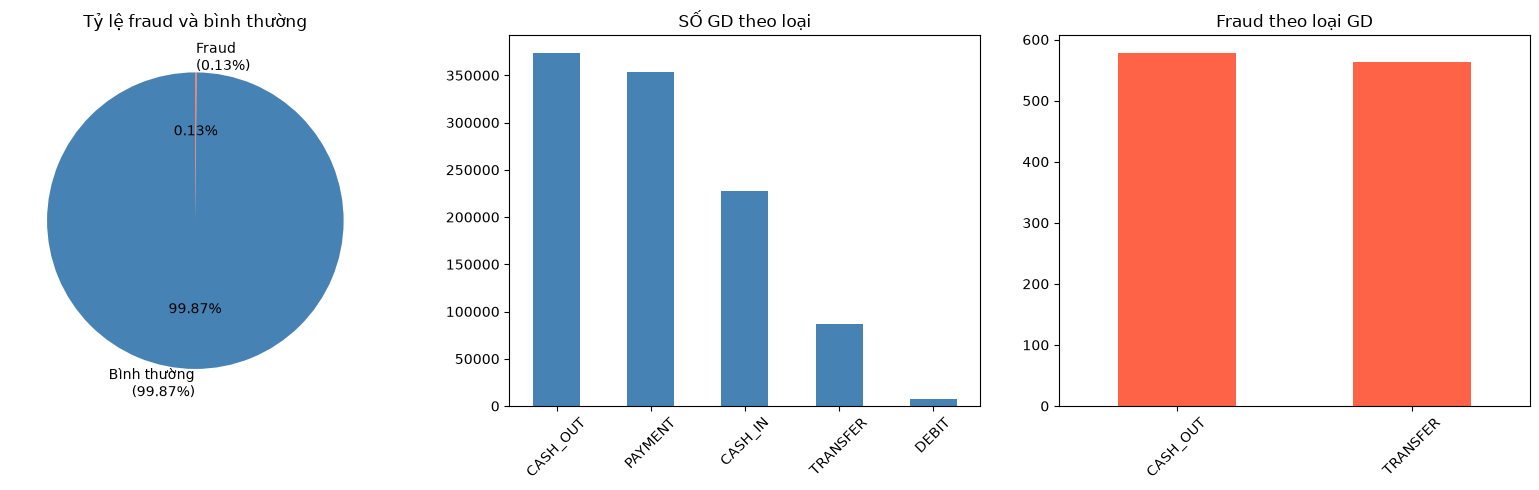

Đã lưu biểu đồ!


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels = ['Bình thường\n(99.87%)', 'Fraud\n(0.13%)']
sizes = [6354407, 8213]
colors = ['steelblue', 'tomato']
axes[0].pie (sizes, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
axes[0].set_title('Tỷ lệ fraud và bình thường')

type_counts = df['type'].value_counts()
type_counts.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('SỐ GD theo loại')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

fraud_counts = df[df['isFraud']==1]['type'].value_counts()
fraud_counts.plot(kind='bar', ax=axes[2], color='tomato')
axes[2].set_title('Fraud theo loại GD')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/01_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ!")

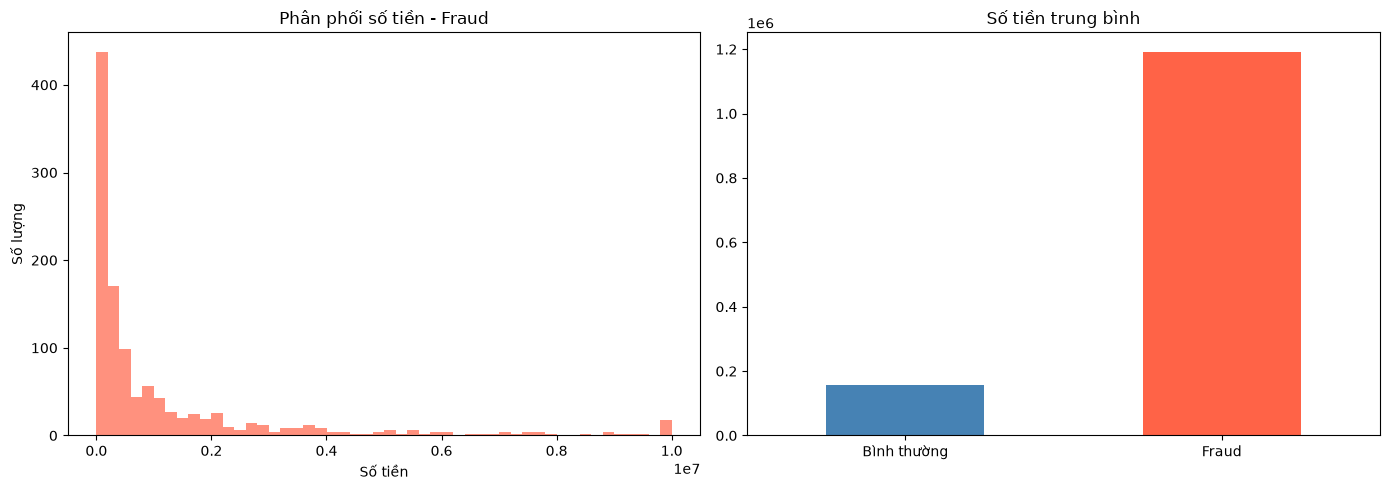

=== THỐNG KÊ SỐ TIỀN ===

Fraud:
count        1142.00
mean      1192628.93
std       2030598.96
min           119.00
25%         86070.17
50%        353179.45
75%       1248759.00
max      10000000.00
Name: amount, dtype: float64

Bình thường:
count    1047433.00
mean      157539.66
std       254188.29
min            0.10
25%        12134.87
50%        76214.97
75%       213492.75
max      6419835.27
Name: amount, dtype: float64


In [20]:
# Phân tích số tiền giao dịch fraud vs bình thường
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud = df[df['isFraud'] == 1]
normal = df[df['isFraud'] == 0]

# Biểu đồ 1: Phân phối số tiền fraud
axes[0].hist(fraud['amount'], bins=50, color='tomato', alpha=0.7)
axes[0].set_title('Phân phối số tiền - Fraud')
axes[0].set_xlabel('Số tiền')
axes[0].set_ylabel('Số lượng')

# Biểu đồ 2: So sánh số tiền trung bình
avg_amount = df.groupby('isFraud')['amount'].mean()
avg_amount.index = ['Bình thường', 'Fraud']
avg_amount.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Số tiền trung bình')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/02_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== THỐNG KÊ SỐ TIỀN ===")
print("\nFraud:")
print(fraud['amount'].describe().round(2))
print("\nBình thường:")
print(normal['amount'].describe().round(2))

In [21]:
df_filtered = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()

df_filtered['hour'] = df_filtered['step'] % 24
df_filtered['is_merchant'] = (df_filtered['nameDest'].str[0] == 'M').astype(int)
df_filtered['errorBalanceOrig'] = df_filtered['oldbalanceOrg'] - df_filtered['newbalanceOrig'] - df_filtered['amount']
df_filtered['errorBalanceDest'] = df_filtered['newbalanceDest'] - df_filtered['oldbalanceDest'] - df_filtered['amount']

In [22]:
features = ['hour', 'amount', 'is_merchant', 'errorBalanceOrig', 'errorBalanceDest','oldbalanceOrg','newbalanceOrig', 'oldbalanceDest', 'newbalanceDest',]

X= df_filtered[features]
y= df_filtered['isFraud']

print(X.shape)
print(y.value_counts())

(460394, 9)
isFraud
0    459252
1      1142
Name: count, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (368315, 9)
Test: (92079, 9)


In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Trước SMOTE: {y_train.value_counts().to_dict()}")
print(f"Sau SMOTE: {y_train_sm.value_counts().to_dict()}")

Trước SMOTE: {0: 367401, 1: 914}
Sau SMOTE: {0: 367401, 1: 367401}


In [25]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sm, y_train_sm)

print("Đã huấn luyện mô hình Logistic Regression với dữ liệu sau SMOTE.")


Đã huấn luyện mô hình Logistic Regression với dữ liệu sau SMOTE.


In [26]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_lr = lr_model.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     91851
           1       0.04      0.90      0.08       228

    accuracy                           0.95     92079
   macro avg       0.52      0.93      0.53     92079
weighted avg       1.00      0.95      0.97     92079

ROC-AUC: 0.9728


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,random_state=42, n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)

print("Đã huấn luyện mô hình Random Forest với dữ liệu sau SMOTE.")

Đã huấn luyện mô hình Random Forest với dữ liệu sau SMOTE.


In [28]:
y_pred_rf = rf_model.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     91851
           1       0.86      0.98      0.92       228

    accuracy                           1.00     92079
   macro avg       0.93      0.99      0.96     92079
weighted avg       1.00      1.00      1.00     92079

ROC-AUC: 0.9931


In [29]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100,random_state=42, n_jobs=-1)
xgb_model.fit(X_train_sm, y_train_sm)

print("Đã huấn luyện mô hình XGBoost với dữ liệu sau SMOTE.")

Đã huấn luyện mô hình XGBoost với dữ liệu sau SMOTE.


In [30]:
y_pred_xgb = xgb_model.predict(X_test)
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     91851
           1       0.71      0.96      0.81       228

    accuracy                           1.00     92079
   macro avg       0.85      0.98      0.91     92079
weighted avg       1.00      1.00      1.00     92079

ROC-AUC: 0.9905


In [31]:
import os
os.makedirs('../models', exist_ok=True)
print("Tạo folder xong!")

Tạo folder xong!


In [32]:
from sklearn.metrics import precision_recall_curve

# Tính threshold tối ưu trước khi đóng gói model.
y_scores = rf_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-8)
)
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

model_package = {
    "model": rf_model,
    "features": features,
    "threshold": float(best_threshold),
    "model_name": "RandomForest",
    "random_state": 42
}

joblib.dump(model_package, '../models/random_forest.pkl')

print(f"Best threshold: {best_threshold:.4f}")
print("Đã lưu model và cấu hình threshold.")

Best threshold: 0.8900
Đã lưu model và cấu hình threshold.


In [33]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Lấy xác suất predict trên test set
y_scores = rf_model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Tìm ngưỡng tốt nhất theo F1
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision: {precision[best_index]:.4f}")
print(f"Recall: {recall[best_index]:.4f}")
print(f"F1-score: {f1_scores[best_index]:.4f}")

Best threshold: 0.8900
Precision: 0.9867
Recall: 0.9781
F1-score: 0.9824


In [34]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_scores)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.9708


In [35]:
y_pred_threshold = (y_scores >= best_threshold).astype(int)

print("=== Kết quả theo best threshold ===")
print(classification_report(y_test, y_pred_threshold))

=== Kết quả theo best threshold ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     91851
           1       0.99      0.98      0.98       228

    accuracy                           1.00     92079
   macro avg       0.99      0.99      0.99     92079
weighted avg       1.00      1.00      1.00     92079



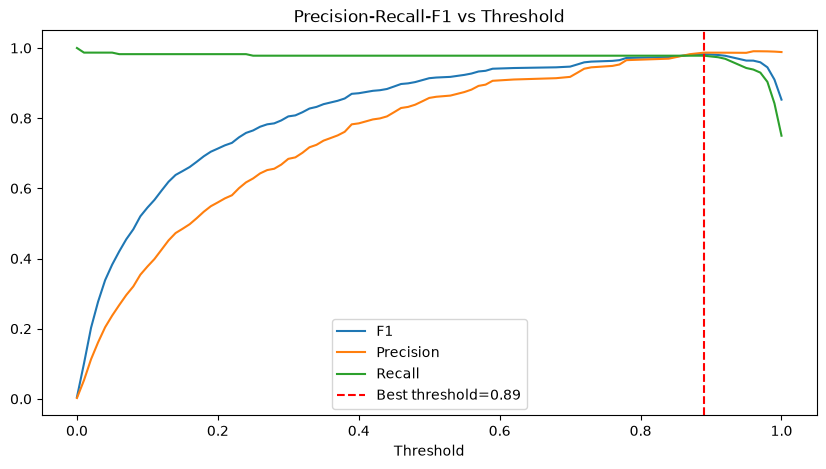

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(thresholds, f1_scores, label='F1')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall-F1 vs Threshold')
plt.show()